## IDS Modeling

Network Duplicate, we need no trainings here

In [1]:
# Import shared surface-potential model
import torch
import matplotlib.pyplot as plt

from SurfacePotential import (
    load_surface_potential_model,
    predict_phis,
)

from Channel_Current_Ich import (
    channel_integral_I_phi,
)


device = "cpu"

dtype = torch.float32

## Parameters transfer
Need to be correspondent

In [2]:
# Physical parameters and surface-PINN domain
T = 300.0

NA = 1.0e16

eps_sic = (
    9.26
    * 8.854e-14
)

Cox = 7.0e-8

Vfbs0 = -1.0

Dit_mid = 2.0e11

Dit_edge = 2.0e13

sigma_it = 0.1

Eg = 3.26

Ec_minus_Ei = (
    Eg / 2.0
)

Qox = 1.602e-7


VGS_MIN = -10.0
VGS_MAX = 30.0

PHIF_MIN = 0.0
PHIF_MAX = 15.0

VDS_MIN = 0.0
VDS_MAX = 15.0


SURFACE_MODEL_PATH = (
    "phis_PINN_surface.pth"
)

We must use the same PINN as PINN_phis.ipynb(of surface potential Φs) to get Φs0, ΦsL(Φs is their substraint)

In [3]:
# Load frozen surface-potential PINN
SurfaceModel = load_surface_potential_model(
    checkpoint=SURFACE_MODEL_PATH,
    device=device,
    dtype=dtype,
    freeze=True,
)


print(
    "Surface-potential PINN loaded:",
    SURFACE_MODEL_PATH
)

Surface-potential PINN loaded: phis_PINN_surface.pth


## Params Definition


In [4]:
# I-V model Eqs. (17)-(21)

K_CURRENT = 1.0e5

LCH_CM = 5.0e-5

LAMBDA_CLM = 0.01

VSAT = 2.0e7

# Vdssat(Vgs) and smooth-transition parameter
DELTA_SAT = 2.0


def calculate_Vdssat(
    Vgs,
):

    Vgs_fit = torch.clamp(
        Vgs,
        min=4.0,
        max=20.0,
    )


    Vdssat = (
        -0.00246543551
        * Vgs_fit**3

        + 0.111959028
        * Vgs_fit**2

        - 0.979219347
        * Vgs_fit

        + 4.21740747
    )


    return torch.clamp(
        Vdssat,
        min=1.7,
        max=10.0,
    )

# Eq. (19) mobility components
MU_B = 900.0

MU_SP = 300.0

MU_C = 500.0

MU_SR = 150.0

MU_DR = 1000.0


# Eq. (19)
def calculate_mu_LF(
    ref,
):

    mu_B = ref.new_tensor(
        MU_B
    )

    mu_SP = ref.new_tensor(
        MU_SP
    )

    mu_C = ref.new_tensor(
        MU_C
    )

    mu_SR = ref.new_tensor(
        MU_SR
    )

    mu_DR = ref.new_tensor(
        MU_DR
    )


    inv_mu_LF = (
        1.0 / mu_B
        + 1.0 / mu_SP
        + 1.0 / mu_C
        + 1.0 / mu_SR
        + 1.0 / mu_DR
    )


    mu_LF = (
        1.0
        / inv_mu_LF
    )


    return (
        torch.ones_like(ref)
        * mu_LF
    )


# Eq. (21)
def calculate_Vds_eff(
    Vds,
):

    Vds = torch.clamp(
        Vds,
        min=0.0,
    )


    Vdssat = Vds.new_tensor(
        VDS_SAT
    )

    Delta = Vds.new_tensor(
        DELTA_SAT
    )

# Eq. (21)
def calculate_Vds_eff(
    Vgs,
    Vds,
):

    Vds = torch.clamp(
        Vds,
        min=0.0,
    )


    Vdssat = calculate_Vdssat(
        Vgs
    )


    Delta = Vds.new_tensor(
        DELTA_SAT
    )


    Vds_eff = (
        Vds
        * (
            1.0
            + (
                Vds
                / Vdssat
            ) ** Delta
        ) ** (
            -1.0
            / Delta
        )
    )


    return Vds_eff

# Eq. (20)
def calculate_mu_eff(
    mu_LF,
    phis_s0,
    phis_sL,
):

    Lch = phis_s0.new_tensor(
        LCH_CM
    )

    vsat = phis_s0.new_tensor(
        VSAT
    )


    Ey = (
        torch.abs(
            phis_sL
            - phis_s0
        )
        / Lch
    )


    a = (
        Ey
        / vsat
    ) ** 2


    a_safe = torch.clamp(
        a,
        min=1.0e-20,
    )


    mu_eff_squared = (
        torch.sqrt(
            1.0
            + 4.0
            * a_safe
            * mu_LF**2
        )
        - 1.0
    ) / (
        2.0
        * a_safe
    )


    mu_eff_squared = torch.where(
        a < 1.0e-12,
        mu_LF**2,
        mu_eff_squared,
    )


    mu_eff = torch.sqrt(
        torch.clamp(
            mu_eff_squared,
            min=0.0,
        )
    )


    return mu_eff


# Complete forward I-V model
@torch.no_grad()
def predict_Ids(
    Vgs,
    Vds,
):

    Vgs = torch.as_tensor(
        Vgs,
        dtype=dtype,
        device=device,
    ).reshape(-1, 1)


    Vds = torch.as_tensor(
        Vds,
        dtype=dtype,
        device=device,
    ).reshape(-1, 1)


    # Eq. (21)
    Vds_eff = calculate_Vds_eff(
    Vgs,
    Vds,
)


    # Source-side surface potential
    phi_f_source = torch.zeros_like(
        Vds_eff
    )


    phis_s0 = predict_phis(
        SurfaceModel,
        Vgs,
        phi_f_source,
        T=T,
        NA=NA,
        eps_sic=eps_sic,
        Cox=Cox,
        Vfbs0=Vfbs0,
        Dit_mid=Dit_mid,
        Dit_edge=Dit_edge,
        sigma_it=sigma_it,
        Eg=Eg,
        dtype=dtype,
        device=device,
    )


    # Drain-side surface potential
    phis_sL = predict_phis(
        SurfaceModel,
        Vgs,
        Vds_eff,
        T=T,
        NA=NA,
        eps_sic=eps_sic,
        Cox=Cox,
        Vfbs0=Vfbs0,
        Dit_mid=Dit_mid,
        Dit_edge=Dit_edge,
        sigma_it=sigma_it,
        Eg=Eg,
        dtype=dtype,
        device=device,
    )


    # Eq. (18)
    I_phi = channel_integral_I_phi(
        Vgs,
        Vds_eff,
        phis_s0,
        phis_sL,
        Vfbs0,
        Cox,
        Qox,
        Dit_mid,
        Dit_edge,
        sigma_it,
        Ec_minus_Ei,
        T,
        NA,
        Eg,
        eps_sic,
    )


    # Eq. (19)
    mu_LF = calculate_mu_LF(
        Vgs
    )


    # Eq. (20)
    mu_eff = calculate_mu_eff(
        mu_LF,
        phis_s0,
        phis_sL,
    )


    K = Vgs.new_tensor(
        K_CURRENT
    )

    lam = Vgs.new_tensor(
        LAMBDA_CLM
    )


    # Eq. (17)
    Ids = (
        K
        * mu_eff
        * (
            1.0
            + lam
            * Vds_eff
        )
        * I_phi
    )


    return torch.clamp(
        Ids,
        min=0.0,
    )

Test1

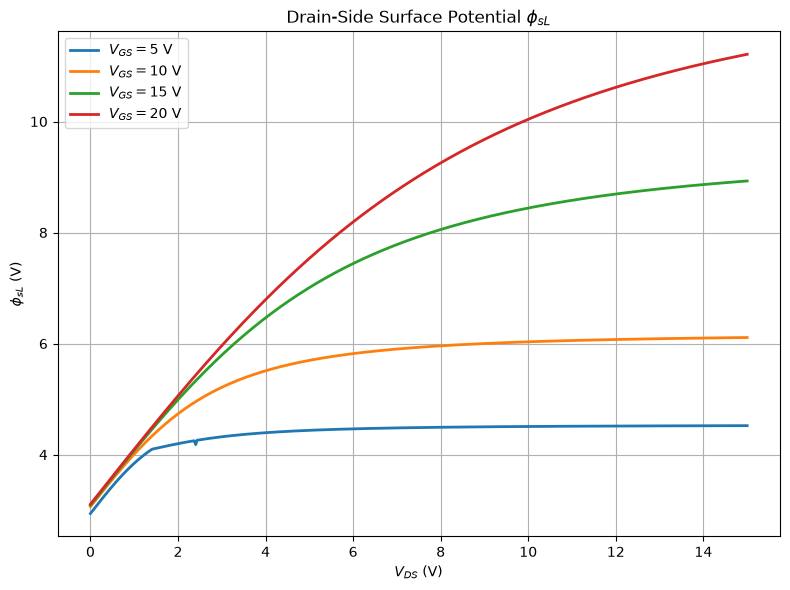

In [5]:
# Check source/drain surface potentials used by the I-V model
N_CHECK = 500

Vds_check = torch.linspace(
    0.0,
    15.0,
    N_CHECK,
    dtype=dtype,
    device=device,
).reshape(-1, 1)

VGS_CHECK = [
    5.0,
    10.0,
    15.0,
    20.0,
]

plt.figure(
    figsize=(8, 6)
)

for VGS_VALUE in VGS_CHECK:

    Vgs_check = torch.full_like(
        Vds_check,
        VGS_VALUE,
    )

    Vds_eff_check = calculate_Vds_eff(
    Vgs_check,
    Vds_check,
)

    phi_f_source = torch.zeros_like(
        Vds_eff_check
    )

    phis_s0_check = predict_phis(
        SurfaceModel,
        Vgs_check,
        phi_f_source,
        T=T,
        NA=NA,
        eps_sic=eps_sic,
        Cox=Cox,
        Vfbs0=Vfbs0,
        Dit_mid=Dit_mid,
        Dit_edge=Dit_edge,
        sigma_it=sigma_it,
        Eg=Eg,
        dtype=dtype,
        device=device,
    )

    phis_sL_check = predict_phis(
        SurfaceModel,
        Vgs_check,
        Vds_eff_check,
        T=T,
        NA=NA,
        eps_sic=eps_sic,
        Cox=Cox,
        Vfbs0=Vfbs0,
        Dit_mid=Dit_mid,
        Dit_edge=Dit_edge,
        sigma_it=sigma_it,
        Eg=Eg,
        dtype=dtype,
        device=device,
    )

    plt.plot(
        Vds_check.cpu().numpy(),
        phis_sL_check.cpu().numpy(),
        linewidth=2,
        label=rf"$V_{{GS}}={VGS_VALUE:.0f}$ V",
    )

plt.xlabel(
    r"$V_{DS}$ (V)"
)

plt.ylabel(
    r"$\phi_{sL}$ (V)"
)

plt.title(
    r"Drain-Side Surface Potential $\phi_{sL}$"
)

plt.grid(
    True
)

plt.legend()

plt.tight_layout()

plt.show()

Test2

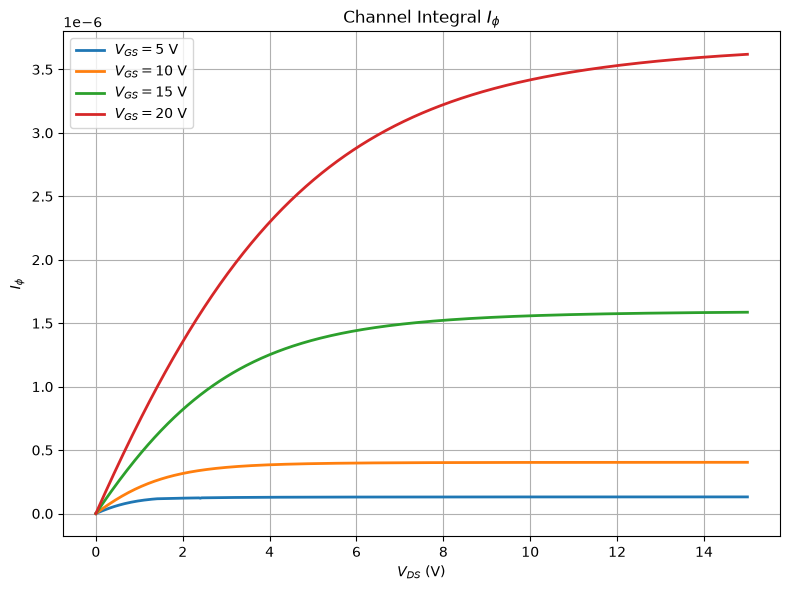

In [6]:
# Check channel integral I_phi before mobility scaling
N_CHECK = 500

Vds_check = torch.linspace(
    0.0,
    15.0,
    N_CHECK,
    dtype=dtype,
    device=device,
).reshape(-1, 1)


VGS_CHECK = [
    5.0,
    10.0,
    15.0,
    20.0,
]


plt.figure(
    figsize=(8, 6)
)


for VGS_VALUE in VGS_CHECK:

    Vgs_check = torch.full_like(
        Vds_check,
        VGS_VALUE,
    )


    Vds_eff_check = calculate_Vds_eff(
    Vgs_check,
    Vds_check,
)


    phis_s0_check = predict_phis(
        SurfaceModel,
        Vgs_check,
        torch.zeros_like(Vds_check),
        T=T,
        NA=NA,
        eps_sic=eps_sic,
        Cox=Cox,
        Vfbs0=Vfbs0,
        Dit_mid=Dit_mid,
        Dit_edge=Dit_edge,
        sigma_it=sigma_it,
        Eg=Eg,
        dtype=dtype,
        device=device,
    )


    phis_sL_check = predict_phis(
        SurfaceModel,
        Vgs_check,
        Vds_eff_check,
        T=T,
        NA=NA,
        eps_sic=eps_sic,
        Cox=Cox,
        Vfbs0=Vfbs0,
        Dit_mid=Dit_mid,
        Dit_edge=Dit_edge,
        sigma_it=sigma_it,
        Eg=Eg,
        dtype=dtype,
        device=device,
    )


    I_phi_check = channel_integral_I_phi(
        Vgs_check,
        Vds_eff_check,
        phis_s0_check,
        phis_sL_check,
        Vfbs0,
        Cox,
        Qox,
        Dit_mid,
        Dit_edge,
        sigma_it,
        Ec_minus_Ei,
        T,
        NA,
        Eg,
        eps_sic,
    )


    plt.plot(
        Vds_check.cpu().numpy(),
        I_phi_check.cpu().numpy(),
        linewidth=2,
        label=rf"$V_{{GS}}={VGS_VALUE:.0f}$ V",
    )


plt.xlabel(
    r"$V_{DS}$ (V)"
)

plt.ylabel(
    r"$I_{\phi}$"
)

plt.title(
    r"Channel Integral $I_{\phi}$"
)

plt.grid(
    True
)

plt.legend()

plt.tight_layout()

plt.show()

Final Transfer

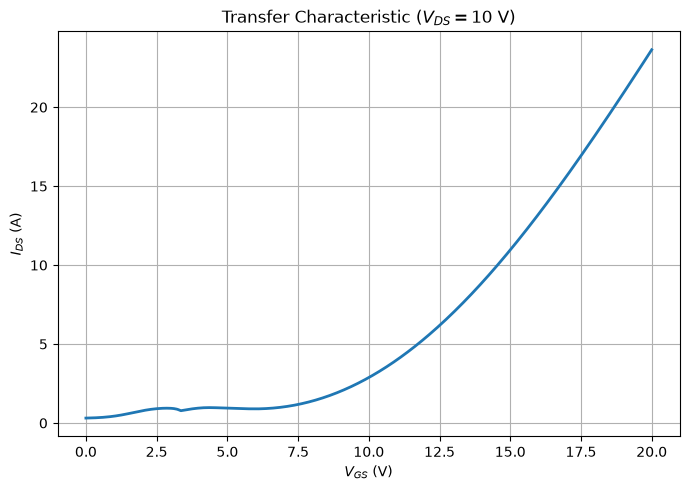

In [7]:
# Fig. 5(b)-style transfer characteristic
N_VGS = 400

VDS_TRANSFER = 10.0


Vgs_transfer = torch.linspace(
    0.0,
    20.0,
    N_VGS,
    dtype=dtype,
    device=device,
).reshape(-1, 1)


Vds_transfer = torch.full_like(
    Vgs_transfer,
    VDS_TRANSFER,
)


Ids_transfer = predict_Ids(
    Vgs_transfer,
    Vds_transfer,
)


plt.figure(
    figsize=(7, 5)
)

plt.plot(
    Vgs_transfer.cpu().numpy(),
    Ids_transfer.cpu().numpy(),
    linewidth=2,
)

plt.xlabel(
    r"$V_{GS}$ (V)"
)

plt.ylabel(
    r"$I_{DS}$ (A)"
)

plt.title(
    r"Transfer Characteristic ($V_{DS}=10$ V)"
)

plt.grid(
    True
)

plt.tight_layout()

plt.show()

Output Curve

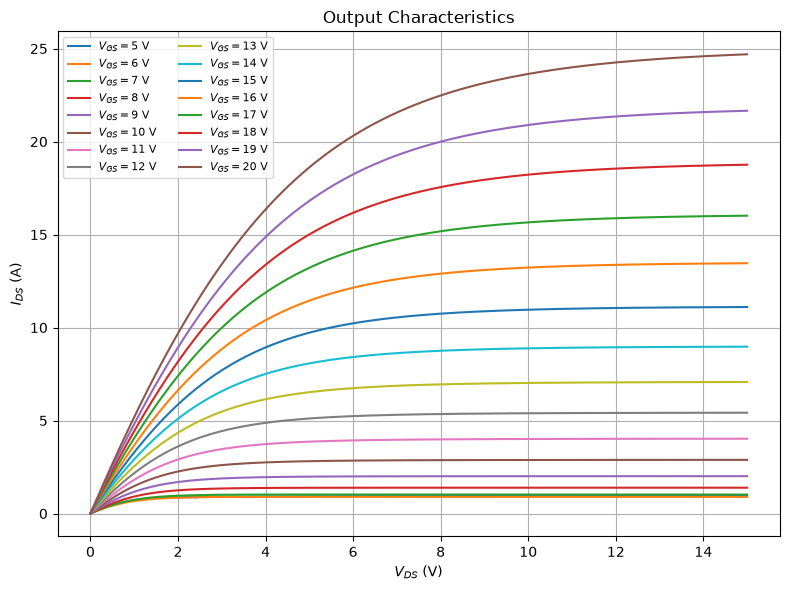

In [8]:
# Fig. 5(a)-style output characteristics
N_VDS = 400


Vds_output = torch.linspace(
    0.0,
    VDS_MAX,
    N_VDS,
    dtype=dtype,
    device=device,
).reshape(-1, 1)


VGS_OUTPUT = [
    5.0,
    6.0,
    7.0,
    8.0,
    9.0,
    10.0,
    11.0,
    12.0,
    13.0,
    14.0,
    15.0,
    16.0,
    17.0,
    18.0,
    19.0,
    20.0,
]


plt.figure(
    figsize=(8, 6)
)


for VGS_VALUE in VGS_OUTPUT:

    Vgs_output = torch.full_like(
        Vds_output,
        VGS_VALUE,
    )


    Ids_output = predict_Ids(
        Vgs_output,
        Vds_output,
    )


    plt.plot(
        Vds_output.cpu().numpy(),
        Ids_output.cpu().numpy(),
        linewidth=1.5,
        label=rf"$V_{{GS}}={VGS_VALUE:.0f}$ V",
    )


plt.xlabel(
    r"$V_{DS}$ (V)"
)

plt.ylabel(
    r"$I_{DS}$ (A)"
)

plt.title(
    "Output Characteristics"
)

plt.grid(
    True
)

plt.legend(
    ncol=2,
    fontsize=8,
)

plt.tight_layout()

plt.show()

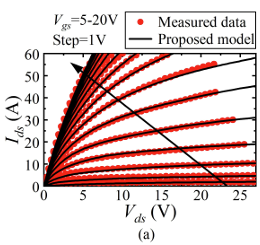